# 4.1 Develop high-resolution cellular maps

## Read the data

In [1]:
!pip install scikit-misc
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

df_tpm = pd.read_csv("/Users/jingyuandu/Downloads/GSE146771_CRC.Leukocyte.10x.TPM.txt.gz", sep="\t", index_col=0)
print(f"Original matrix shape (genes x cells): {df_tpm.shape}")

df_meta = pd.read_csv("/Users/jingyuandu/Downloads/GSE146771_CRC.Leukocyte.10x.Metadata.txt.gz", sep="\t")
print(f"Metadata Shape:{df_meta.shape}")

df_meta.head()

Original matrix shape (genes x cells): (13538, 0)
Metadata Shape:(43817, 23)


,Sample_BarcodeID,CellName,Sample,Tissue,Platform,raw.nUMI,raw.nGene,filter.nUMI,filter.nGene,ribo.per,...,raw.nLR,Global_Cluster,Sub_Cluster,Sub_ClusterID,Global_tSNE_1,Global_tSNE_2,Sub_tSNE_1,Sub_tSNE_2,integrated.Global_tSNE_1,integrated.Global_tSNE_2
0,CRC_P1025_L01_AAACGGGAGGGCTTGA,P_N_P1025_00001,P1025,N,10X,2378,922,2328,892,0.304878,...,27,CD4 T cell,hT04_CD4-TCF7,hT04,-22.378793,-9.359008,-16.215810,-10.585543,8.232381,7.464753
1,CRC_P1025_L01_AACCATGAGACTAGGC,P_N_P1025_00002,P1025,N,10X,4891,1425,4800,1380,0.361685,...,59,CD4 T cell,hT05_CD4-CXCR6,hT05,-17.819294,-9.509335,-3.283048,-9.810943,3.796405,0.368190
2,CRC_P1025_L01_AACTGGTGTATATGAG,P_N_P1025_00003,P1025,N,10X,4578,1341,4484,1307,0.404543,...,54,CD4 T cell,hT07_CD4-GZMK,hT07,-16.022199,-4.865015,-5.169839,0.773927,9.929026,-0.864407
3,CRC_P1025_L01_AAGCCGCTCTTCGGTC,P_N_P1025_00004,P1025,N,10X,4209,1390,4133,1345,0.313376,...,51,CD4 T cell,hT05_CD4-CXCR6,hT05,-17.410715,-9.170012,-1.073856,-10.615394,3.458421,-0.700463
4,CRC_P1025_L01_AATCCAGGTAGCCTCG,P_N_P1025_00005,P1025,N,10X,3660,1496,3583,1461,0.181148,...,48,CD4 T cell,hT05_CD4-CXCR6,hT05,-4.538776,-10.230234,16.120448,-5.141835,1.052564,-15.070587


## Construct Anndata

In [2]:
if "CellName" in df_meta.columns:
    df_meta.set_index("CellName", inplace=True)
elif "Sample_BarcodeID" in df_meta.columns:
    df_meta.set_index("Sample_BarcodeID", inplace=True)

# transpose the expression matrix
df_tpm_T = df_tpm.T
common_cells = df_tpm_T.index.intersection(df_meta.index)
print(f"Total number of cells: {len(common_cells)}")

# construct AnnData
df_tpm_clean = df_tpm_T.loc[common_cells]
df_meta_clean = df_meta.loc[common_cells]

adata = ad.AnnData(X=df_tpm_clean.values)
adata.obs_names = df_tpm_clean.index.astype(str)
adata.var_names = df_tpm_clean.columns.astype(str)
adata.obs = df_meta_clean

print("\nAnnData objects:")
print(adata)

Total number of cells: 0

AnnData objects:
AnnData object with n_obs × n_vars = 0 × 13538
    obs: 'Sample_BarcodeID', 'Sample', 'Tissue', 'Platform', 'raw.nUMI', 'raw.nGene', 'filter.nUMI', 'filter.nGene', 'ribo.per', 'raw.nCD', 'raw.nTF', 'raw.nCyt', 'raw.nLR', 'Global_Cluster', 'Sub_Cluster', 'Sub_ClusterID', 'Global_tSNE_1', 'Global_tSNE_2', 'Sub_tSNE_1', 'Sub_tSNE_2', 'integrated.Global_tSNE_1', 'integrated.Global_tSNE_2'


In [3]:
import pandas as pd
import anndata as ad
import scanpy as sc

tpm_path = "/Users/jingyuandu/Downloads/GSE146771_CRC.Leukocyte.10x.TPM.txt.gz"
meta_path = "/Users/jingyuandu/Downloads/GSE146771_CRC.Leukocyte.10x.Metadata.txt.gz"

df_tpm = pd.read_csv(tpm_path, sep=" ", index_col=0)
df_meta = pd.read_csv(meta_path, sep="\t")

tpm_cells = df_tpm.columns
match_col = None


if len(tpm_cells.intersection(df_meta.index)) > 0:
    match_col = "index"
else:
    for col in df_meta.columns:
        if len(tpm_cells.intersection(df_meta[col])) > 0:
            match_col = col
            break

if match_col:
    print(f"found a matching column.: '{match_col}'")
    if match_col != "index":
        df_meta.set_index(match_col, inplace=True)
else:
    print("No matching columns found")


# construct AnnData
df_tpm_T = df_tpm.T
common_cells = df_tpm_T.index.intersection(df_meta.index)
print(f"Final total cell count: {len(common_cells)}")

df_tpm_clean = df_tpm_T.loc[common_cells]
df_meta_clean = df_meta.loc[common_cells]

adata = ad.AnnData(X=df_tpm_clean.values)
adata.obs_names = df_tpm_clean.index.astype(str)
adata.var_names = df_tpm_clean.columns.astype(str)
adata.obs = df_meta_clean

print("\n AnnData objects:")
print(adata)

found a matching column.: 'CellName'
Final total cell count: 43817

 AnnData objects:
AnnData object with n_obs × n_vars = 43817 × 13538
    obs: 'Sample_BarcodeID', 'Sample', 'Tissue', 'Platform', 'raw.nUMI', 'raw.nGene', 'filter.nUMI', 'filter.nGene', 'ribo.per', 'raw.nCD', 'raw.nTF', 'raw.nCyt', 'raw.nLR', 'Global_Cluster', 'Sub_Cluster', 'Sub_ClusterID', 'Global_tSNE_1', 'Global_tSNE_2', 'Sub_tSNE_1', 'Sub_tSNE_2', 'integrated.Global_tSNE_1', 'integrated.Global_tSNE_2'


## Data preprocessing and Extract highly variable genes

In [4]:
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.raw = adata

adata = adata[:, adata.var.highly_variable]

## PCA and UMAP

/opt/anaconda3/envs/sc-env/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


 PCA dimensionality reduction completed.


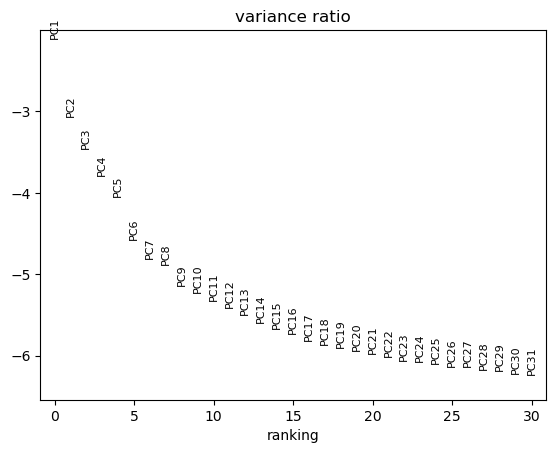

/opt/anaconda3/envs/sc-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


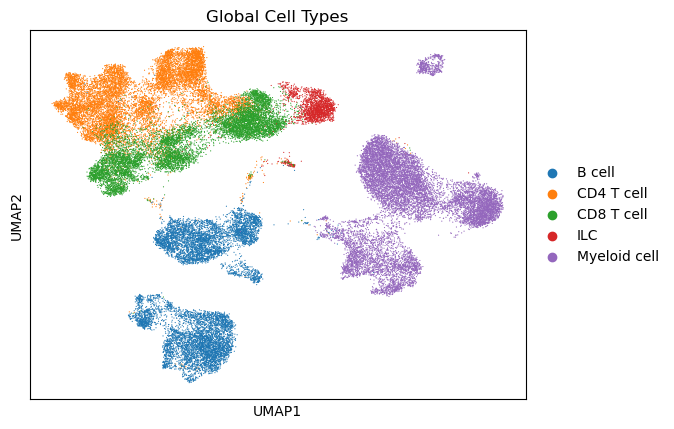

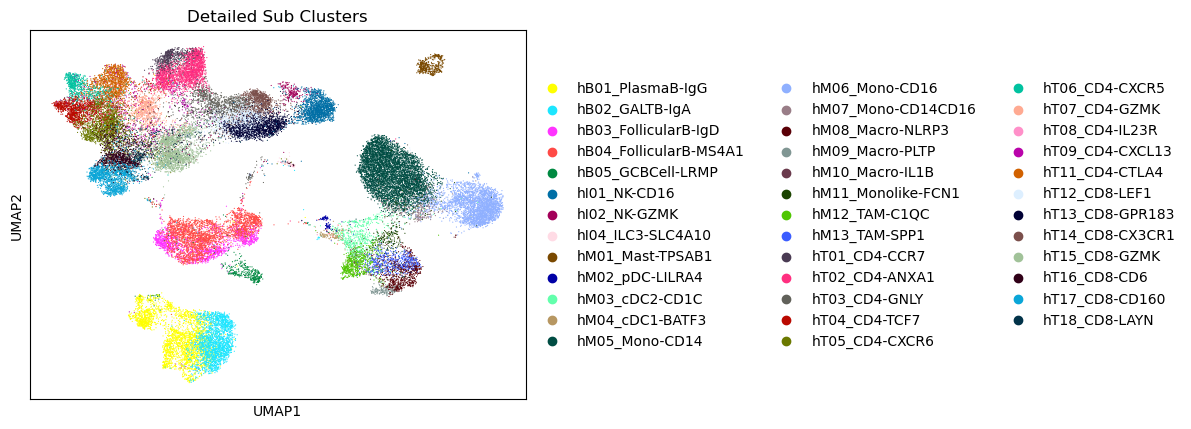

In [5]:
sc.tl.pca(adata, svd_solver="arpack")
print(" PCA dimensionality reduction completed.")

# Draw scree plot
sc.pl.pca_variance_ratio(adata, log=True)

# UMAP
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

# broad categories defined by the author
sc.pl.umap(adata, color=["Global_Cluster"], title="Global Cell Types")

# fine-grained subpopulations
sc.pl.umap(adata, color=["Sub_Cluster"], title="Detailed Sub Clusters")

# 4.3 Comparison within subsets

<Figure size 1000x800 with 0 Axes>

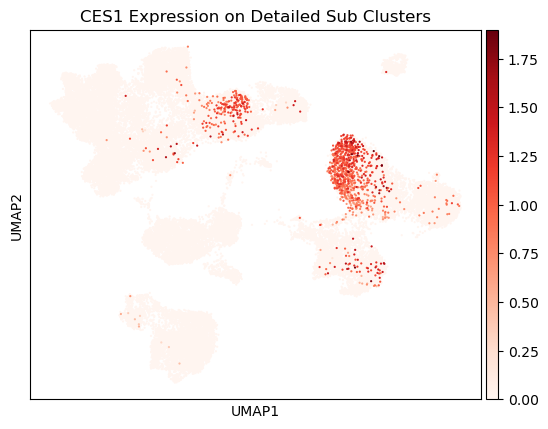

KeyError: "Could not find keys ['Detailed Sub Clusters'] in columns of `adata.obs` or in adata.raw.var_names."

<Figure size 2000x600 with 0 Axes>

In [6]:
import scanpy as sc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sc.pl.umap(adata, color=['CES1'], cmap='Reds', size=10, show=False)
plt.title("CES1 Expression on Detailed Sub Clusters")
plt.show()

plt.figure(figsize=(20, 6))
sc.pl.violin(adata, keys='CES1', groupby='Detailed Sub Clusters', rotation=90)
plt.show()

In [7]:
import scanpy as sc
import anndata as ad

# 1. Filter out all subpopulations starting with 'hM' (Human Myeloid)
myeloid_clusters = [f'hM{i:02d}' for i in range(1, 14)]

# 2. Separately extract the cells belonging to these 13 subpopulations from the original adata
adata_myeloid = adata[adata.obs['Sub_ClusterID'].isin(myeloid_clusters)].copy()

# 3. Print the count of the isolated myeloid cells
print("Isolate myeloid cell subsets:")
print(adata_myeloid)

Isolate myeloid cell subsets:
AnnData object with n_obs × n_vars = 12625 × 2000
    obs: 'Sample_BarcodeID', 'Sample', 'Tissue', 'Platform', 'raw.nUMI', 'raw.nGene', 'filter.nUMI', 'filter.nGene', 'ribo.per', 'raw.nCD', 'raw.nTF', 'raw.nCyt', 'raw.nLR', 'Global_Cluster', 'Sub_Cluster', 'Sub_ClusterID', 'Global_tSNE_1', 'Global_tSNE_2', 'Sub_tSNE_1', 'Sub_tSNE_2', 'integrated.Global_tSNE_1', 'integrated.Global_tSNE_2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Global_Cluster_colors', 'Sub_Cluster_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


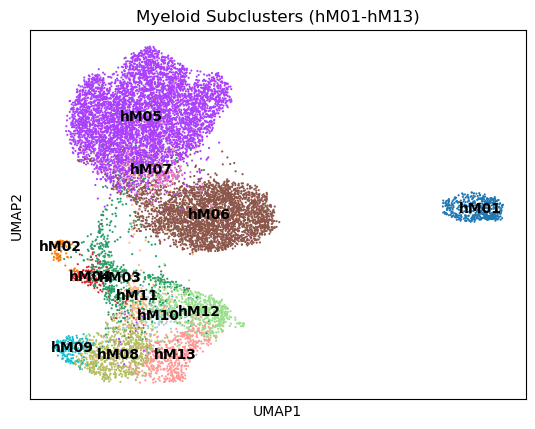

In [8]:
# 1. Re-extract hypervariable genes from within myeloid cells
sc.pp.highly_variable_genes(adata_myeloid, min_mean=0.0125, max_mean=3, min_disp=0.5)

# 2. Re-perform PCA dimensionality reduction
sc.tl.pca(adata_myeloid, svd_solver='arpack')

# 3. Reconstructing the Neighbourhood Graph and UMAP
sc.pp.neighbors(adata_myeloid, n_neighbors=15, n_pcs=20)
sc.tl.umap(adata_myeloid)

# 4. Generate a high-resolution UMAP map specific to the myeloid lineage.
sc.pl.umap(adata_myeloid, color='Sub_ClusterID', title='Myeloid Subclusters (hM01-hM13)', legend_loc='on data')

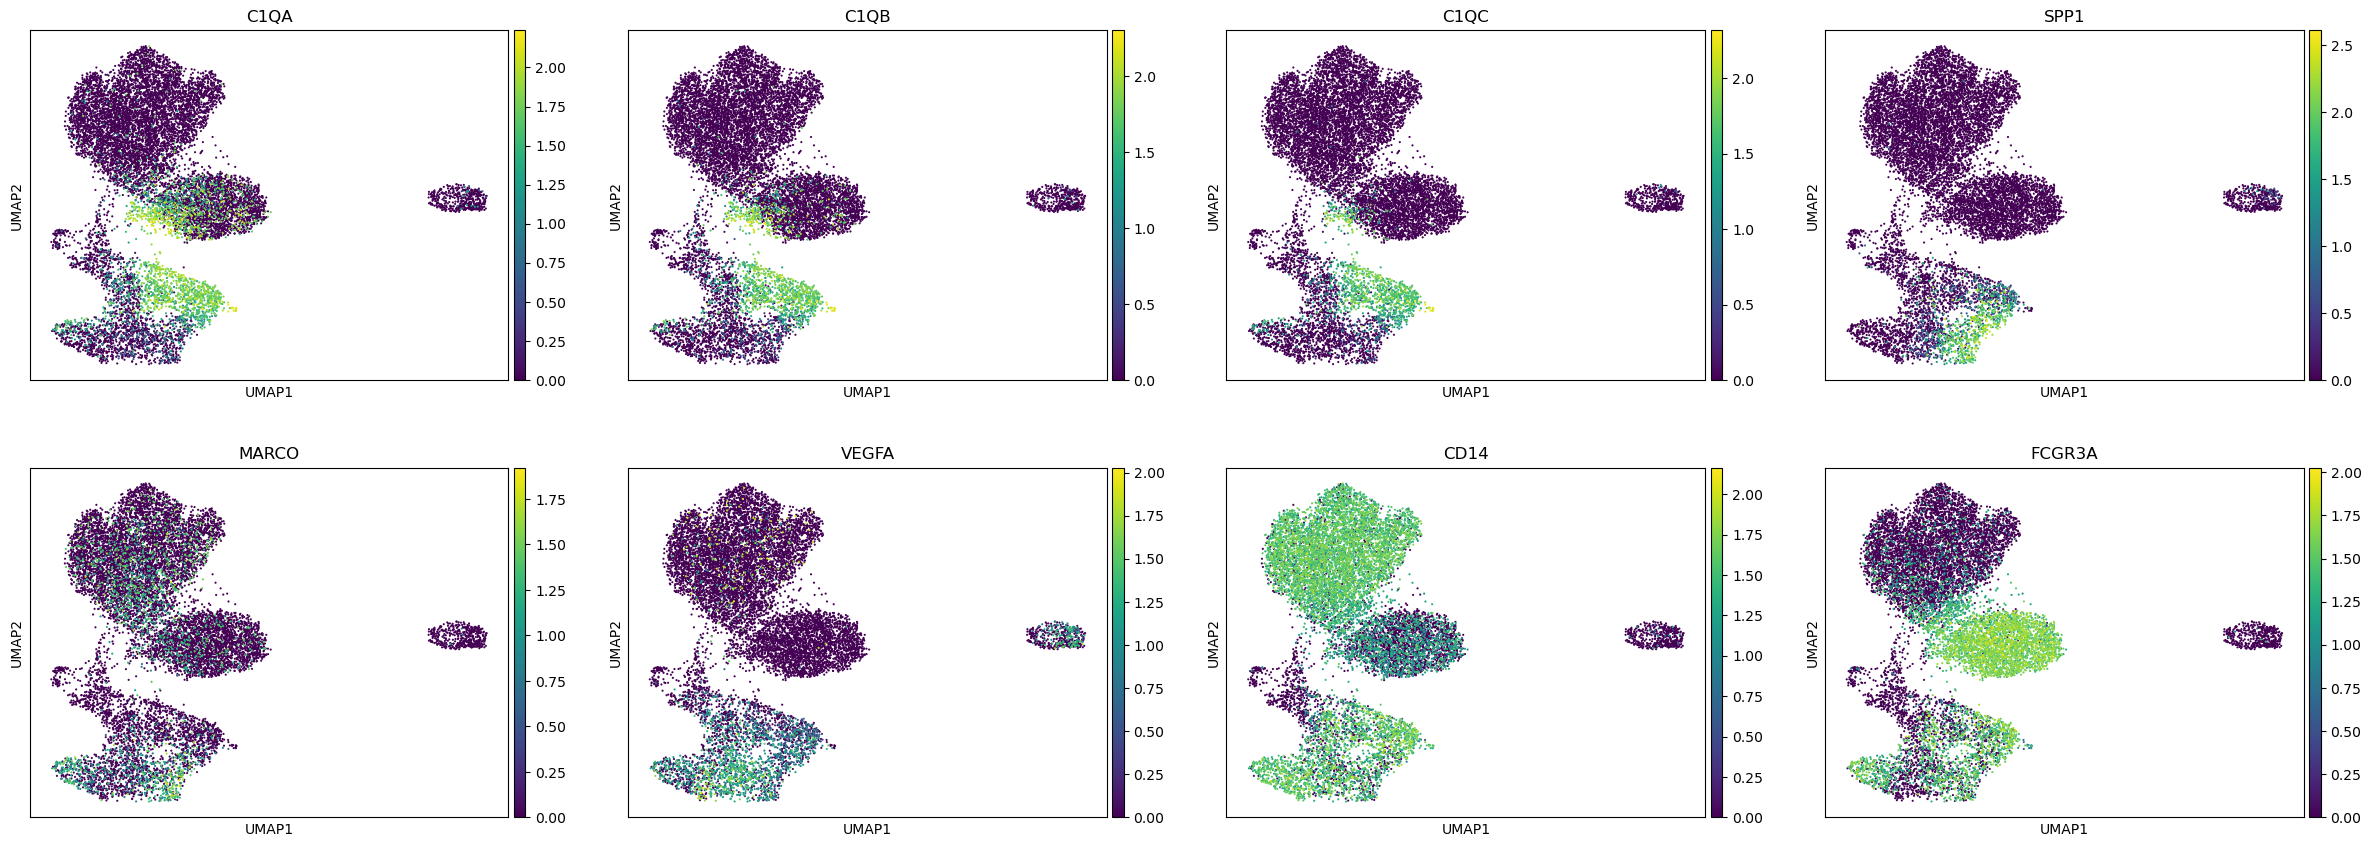

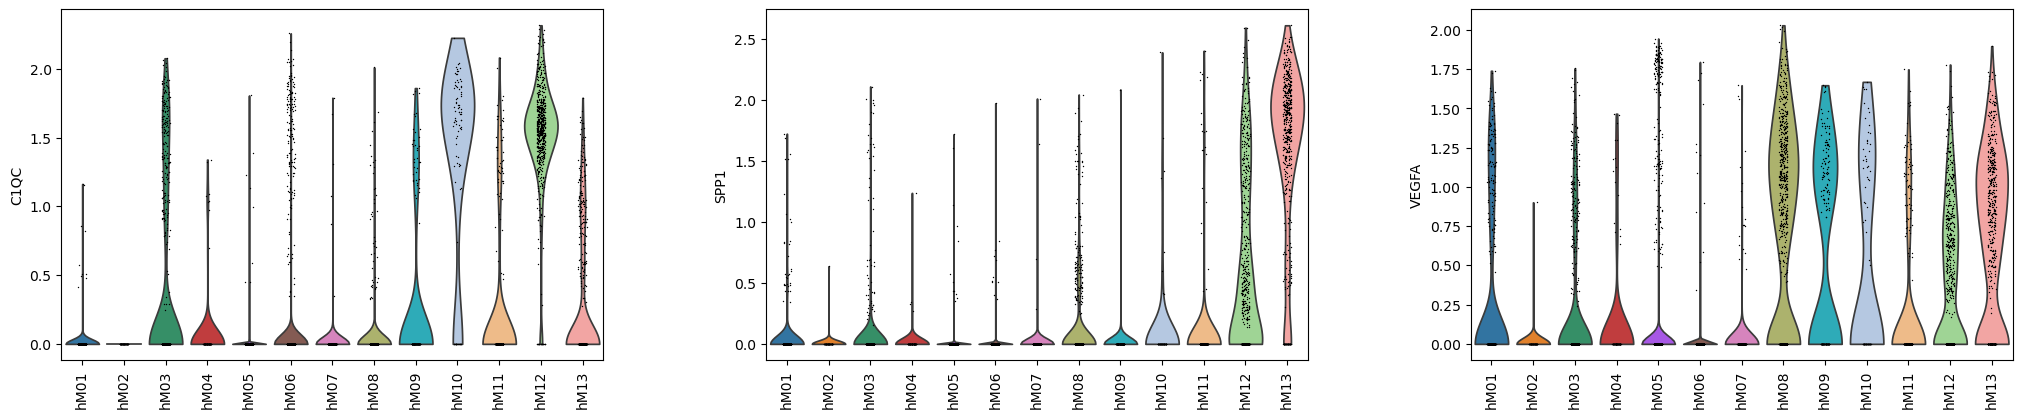

In [9]:
# Define the list of key marker genes from the article
marker_genes = ['C1QA', 'C1QB', 'C1QC', 'SPP1', 'MARCO', 'VEGFA', 'CD14', 'FCGR3A']

# 1. Generate a UMAP scatter plot of gene expression
sc.pl.umap(adata_myeloid, color=marker_genes, ncols=4)

# 2. Plot violin plots
sc.pl.violin(adata_myeloid, keys=['C1QC', 'SPP1', 'VEGFA'], groupby='Sub_ClusterID', rotation=90)

Extracted bone marrow cells： 12625


/var/folders/xz/_qm1qp5x0hdcqs8lw8c4s8cr0000gn/T/ipykernel_2040/1931739343.py:22: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_myeloid, resolution=0.8, key_added='myeloid_clusters')


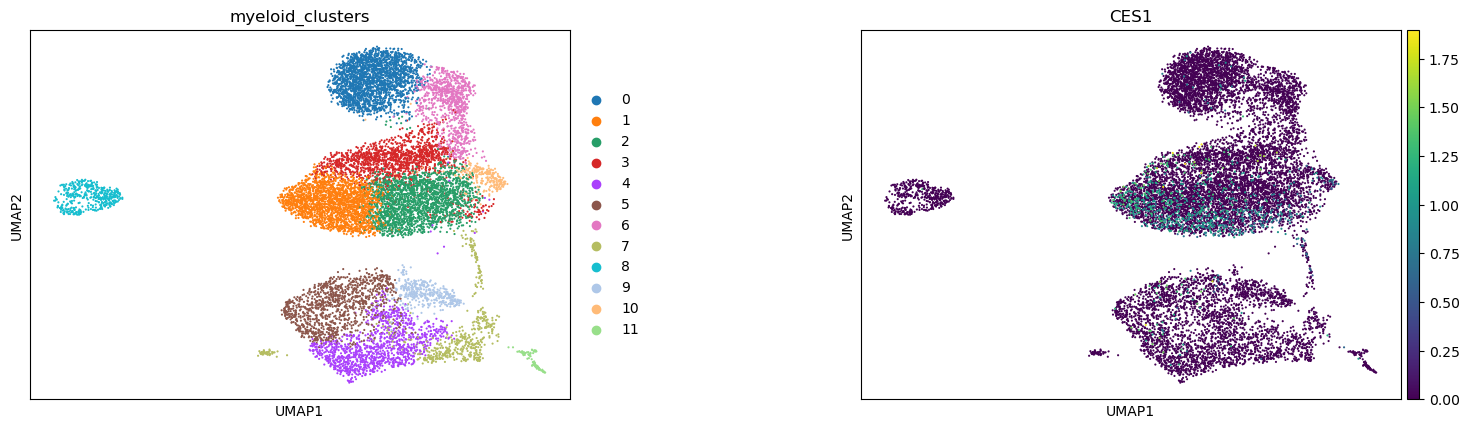

In [10]:
import scanpy as sc
import pandas as pd
import numpy as np
import os

# 1. Load the processed AnnData object
adata_cpdb = sc.read_h5ad("/Users/jingyuandu/Desktop/Dissertation Project/zhang_processed.h5ad")

# 2. Extract cells classified as myeloid cells from the Global dataset
adata_myeloid = adata_cpdb[adata_cpdb.obs['Global_Cluster'] == 'Myeloid cell'].copy()
print("Extracted bone marrow cells：", adata_myeloid.shape[0])

# 3. Re-perform highly variable gene selection, PCA, and neighbour calculation for this subset.
sc.pp.highly_variable_genes(adata_myeloid, flavor="seurat", n_top_genes=2000)
sc.tl.pca(adata_myeloid, svd_solver="arpack")
sc.pp.neighbors(adata_myeloid, n_neighbors=15, n_pcs=30)

# 4. UMAP dimensionality reduction
sc.tl.umap(adata_myeloid)

# 5. Re-cluster using the Leiden algorithm
sc.tl.leiden(adata_myeloid, resolution=0.8, key_added='myeloid_clusters')

# 6. Generate a high-resolution UMAP plot of bone marrow cells
sc.pl.umap(adata_myeloid, color=['myeloid_clusters', 'CES1'], wspace=0.4)

Running Leiden clustering...

=== Correspondence table between Leiden clustering IDs (0–9) and expert annotations (hM) ===
Leiden clustering 0 -- corresponds to: hM06
Leiden clustering 1 -- corresponds to: hM05
Leiden clustering 2 -- corresponds to: hM05
Leiden clustering 3 -- corresponds to: hM05
Leiden clustering 4 -- corresponds to: hM12
Leiden clustering 5 -- corresponds to: hM08
Leiden clustering 6 -- corresponds to: hM06
Leiden clustering 7 -- corresponds to: hM03
Leiden clustering 8 -- corresponds to: hM01
Leiden clustering 9 -- corresponds to: hM09
Leiden clustering 10 -- corresponds to: hM07
Leiden clustering 11 -- corresponds to: hM02


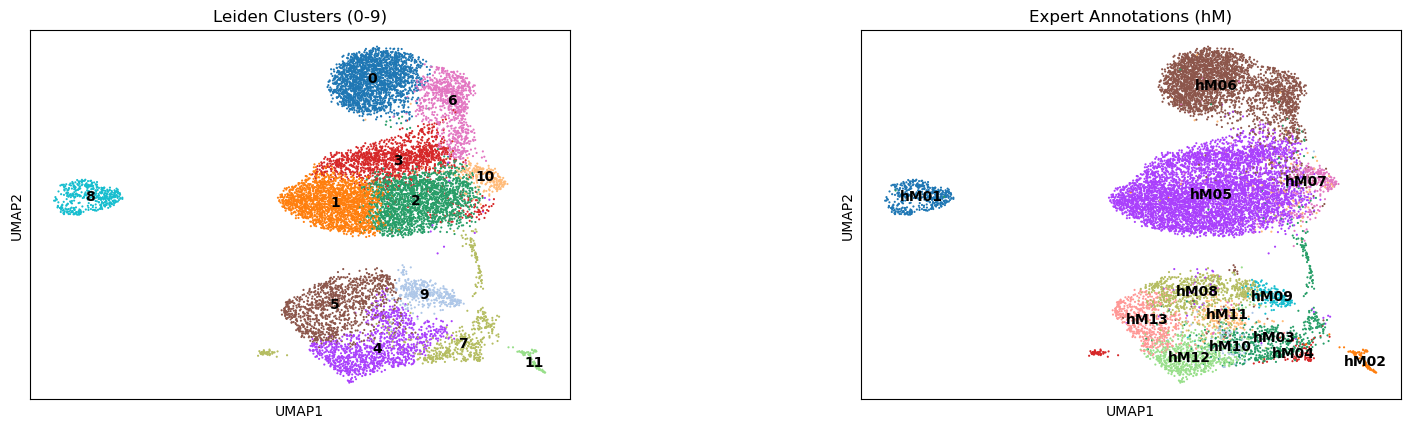

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Running Leiden clustering...")
# 1. Re-perform unsupervised clustering
sc.tl.leiden(adata_myeloid, resolution=0.8, key_added='myeloid_clusters')

# 2. Calculate the overlap (cross-tabulation) between clusters 0–9 and the original author's hM subpopulations
mapping_df = pd.crosstab(adata_myeloid.obs['myeloid_clusters'], adata_myeloid.obs['Sub_ClusterID'])

print("\n=== Correspondence table between Leiden clustering IDs (0–9) and expert annotations (hM) ===")
# Identify the hM subpopulation identity that is most represented in each cluster (0–9)
for cluster_id in mapping_df.index:
    top_match = mapping_df.loc[cluster_id].idxmax()
    print(f"Leiden clustering {cluster_id} -- corresponds to: {top_match}")

# 3. Create a side-by-side comparison chart
sc.pl.umap(
    adata_myeloid, 
    color=['myeloid_clusters', 'Sub_ClusterID'], 
    wspace=0.4,                  
    title=['Leiden Clusters (0-9)', 'Expert Annotations (hM)'],
    legend_loc='on data',        
    legend_fontsize=10,
    show=True
)

Available column names in the data： ['Sample_BarcodeID', 'Sample', 'Tissue', 'Platform', 'raw.nUMI', 'raw.nGene', 'filter.nUMI', 'filter.nGene', 'ribo.per', 'raw.nCD', 'raw.nTF', 'raw.nCyt', 'raw.nLR', 'Global_Cluster', 'Sub_Cluster', 'Sub_ClusterID', 'Global_tSNE_1', 'Global_tSNE_2', 'Sub_tSNE_1', 'Sub_tSNE_2', 'integrated.Global_tSNE_1', 'integrated.Global_tSNE_2', 'Merged_Cluster', 'myeloid_clusters']
Percentage distribution of subpopulations across tissues：


Tissue,N,P,T
Sub_ClusterID,,,
hM01,12.390244,0.011061,12.309496
hM02,0.878049,0.564097,1.133255
hM03,18.829268,1.891384,10.707308
hM04,4.487805,0.033182,2.735444
hM05,4.390244,59.252295,2.071122
hM06,2.048780,33.713085,1.016022
hM07,0.878049,3.749585,0.234467
hM08,22.926829,0.077425,18.132083
hM09,18.146341,0.000000,0.078156


<Figure size 1000x600 with 0 Axes>

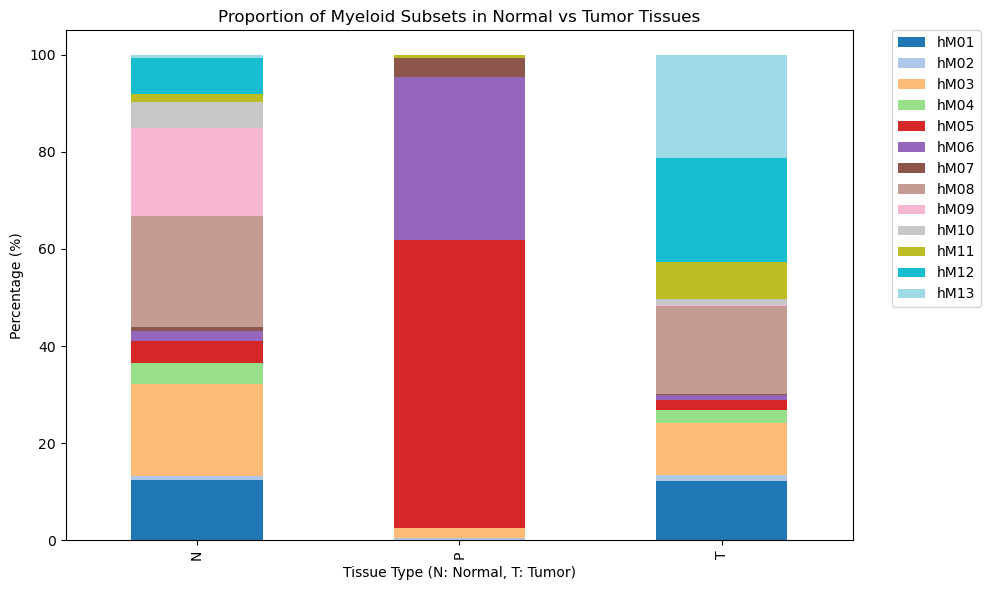

In [12]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Check the data
print("Available column names in the data：", adata_myeloid.obs.columns.tolist())

# 2. Calculate the cell proportions of various myeloid subpopulations in Normal (N) and Tumor (T) samples
cluster_key = 'Sub_ClusterID' if 'Sub_ClusterID' in adata_myeloid.obs.columns else 'cell_type'

# Use crosstab to calculate frequencies and convert them to percentages.
ct = pd.crosstab(adata_myeloid.obs[cluster_key], adata_myeloid.obs['Tissue'], normalize='columns') * 100
print("Percentage distribution of subpopulations across tissues：")
display(ct)

# 3. Create stacked bar plots
plt.figure(figsize=(10, 6))
ct.T.plot(kind='bar', stacked=True, colormap='tab20', figsize=(10, 6))
plt.title("Proportion of Myeloid Subsets in Normal vs Tumor Tissues")
plt.xlabel("Tissue Type (N: Normal, T: Tumor)")
plt.ylabel("Percentage (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

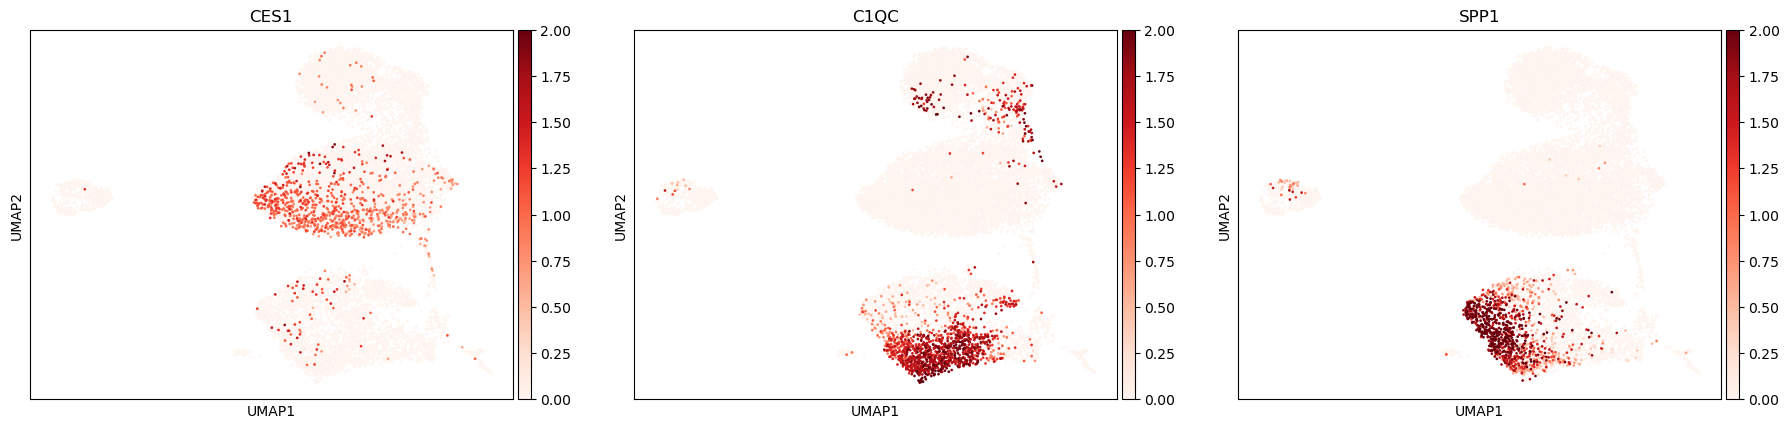

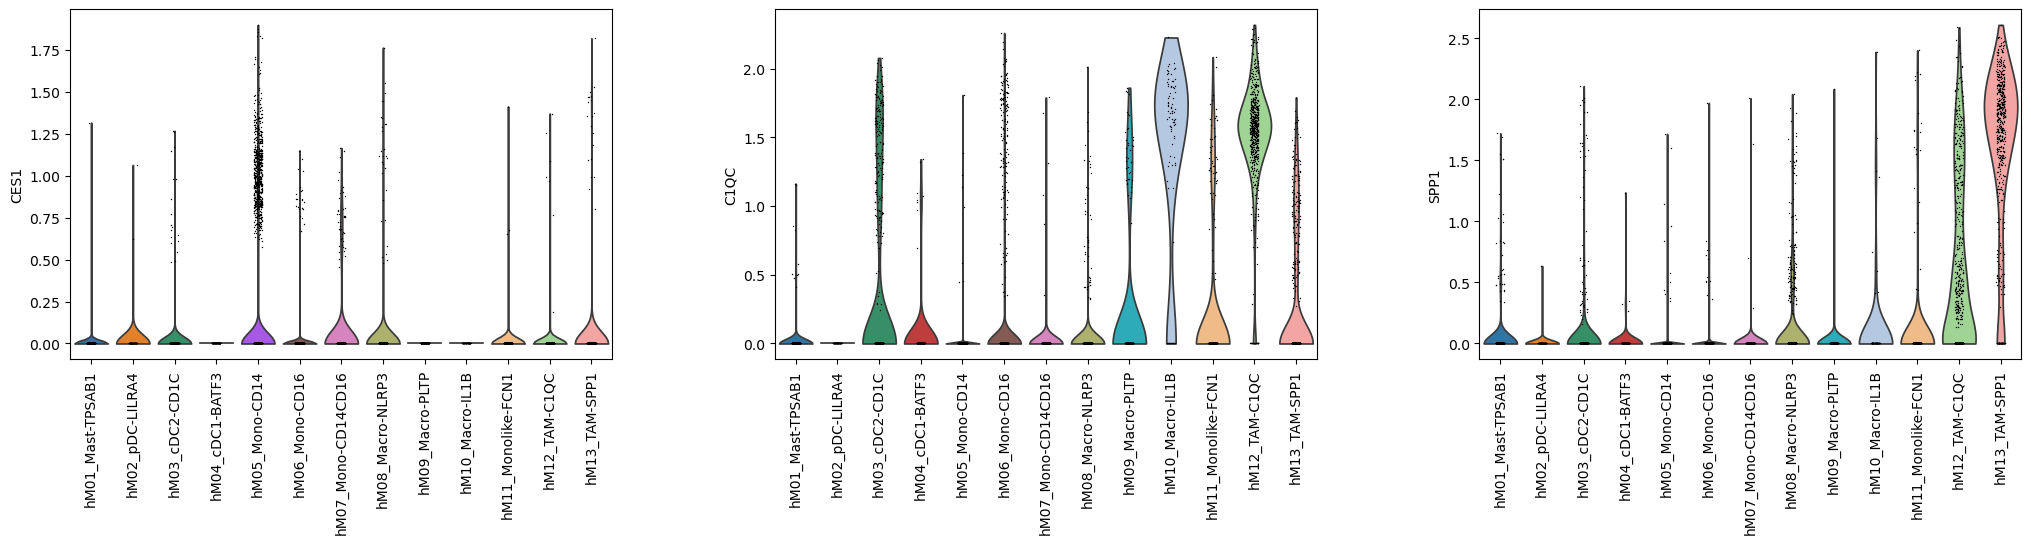

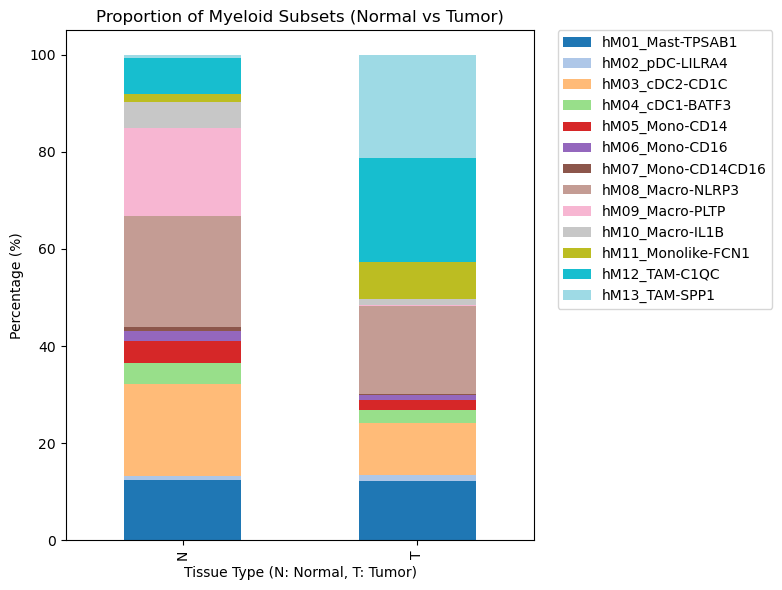

In [13]:
import matplotlib.pyplot as plt

# Plot the UMAP expression distributions of CES1, C1QC, and SPP1.
## vmin=0, vmax=1.5 
## The darker the colour, the higher the level of cellular expression.
sc.pl.umap(adata_myeloid, color=['CES1', 'C1QC', 'SPP1'], cmap='Reds', size=15, vmin=0, vmax=2)

# Plot violin plots
sc.pl.violin(adata_myeloid, keys=['CES1', 'C1QC', 'SPP1'], groupby='Sub_Cluster', rotation=90)

# Improve stacked barplot
adata_myeloid_nt = adata_myeloid[adata_myeloid.obs['Tissue'].isin(['N', 'T'])].copy()
ct = pd.crosstab(adata_myeloid_nt.obs['Sub_Cluster'], adata_myeloid_nt.obs['Tissue'], normalize='columns') * 100

# Draw
ct.T.plot(kind='bar', stacked=True, colormap='tab20', figsize=(8, 6))
plt.title("Proportion of Myeloid Subsets (Normal vs Tumor)")
plt.xlabel("Tissue Type (N: Normal, T: Tumor)")
plt.ylabel("Percentage (%)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [18]:
import os
import pandas as pd

data_dir = "./cpdb_inputs"
os.makedirs(data_dir, exist_ok=True)

meta_global = pd.DataFrame({
    'cell': adata.obs_names,
    'cell_type': adata.obs['Global_Cluster'] 
})
meta_global_path = os.path.join(data_dir, "metadata_global.tsv")
meta_global.to_csv(meta_global_path, sep='\t', index=False)

print(f"Major category metadata exported! Save to {meta_global_path}")

Major category metadata exported! Save to ./cpdb_inputs/metadata_global.tsv
